Data source and info (metadata):  
Elections: https://geodacenter.github.io/data-and-lab/county_election_2012_2016-variables/ 


Guerry (the data used for demo in the lecture): https://geodacenter.github.io/data-and-lab/Guerry/ 

About Geoda: https://geodacenter.github.io/

To use the math symbol from Latex: https://oeis.org/wiki/List_of_LaTeX_mathematical_symbols 

e.g.,
- `$\leq$` becomes $\leq$
- `$\geq$` becomes $\geq$


In [32]:
import os
import timeit
import random
import pandas as pd
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
from shapely.geometry import Point

import numpy as np
from pysal.lib import weights
from libpysal.weights import lat2W, higher_order
from pysal.explore import esda
#from pysal.viz.splot.esda import moran_scatterplot, lisa_cluster, plot_local_autocorrelation
import splot
from splot.esda import moran_scatterplot, lisa_cluster, plot_local_autocorrelation
import mapclassify

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


from tqdm import tqdm

In [2]:
os.listdir('../resources/election')

['election.prj',
 'election.dbf',
 'election.shx',
 'election_queen.gal',
 'election.shp']

<Axes: >

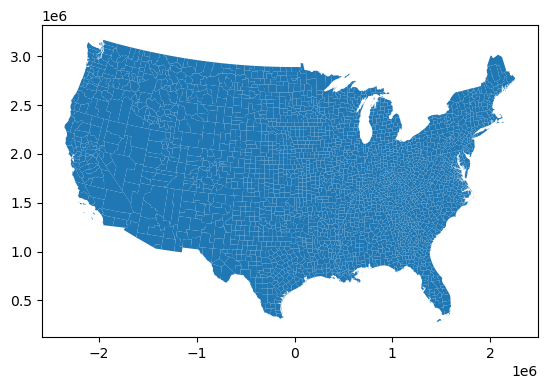

In [3]:
gdf = gpd.read_file('../resources/election/election.shp')
gdf.crs = 'epsg:4326'
gdf = gdf.to_crs('epsg:5070')
gdf = gdf.reset_index()
gdf.plot()

In [4]:
gdf.head()

,index,STATEFP,COUNTYFP,GEOID,ALAND,AWATER,area_name,state_abbr,PST045214,PST040210,...,total_2012,Demvotes12,GOPvotes12,county_fip,state_fips,pct_dem_12,pct_gop_12,diff_2012,pct_pt_12,geometry
0,0,01,005,01005,2.291821e+09,50864677.0,Barbour County,AL,26887.0,27457.0,...,11459.0,5873.0,5539.0,5.0,1.0,0.512523,0.483376,334.0,0.029147,"POLYGON ((966818.148 1001565.672, 967065.502 1..."
1,1,01,023,01023,2.365955e+09,19059247.0,Choctaw County,AL,13323.0,13858.0,...,7965.0,3785.0,4150.0,23.0,1.0,0.475204,0.521030,365.0,-0.045825,"POLYGON ((708032.013 1008009.585, 708119.103 1..."
2,2,01,035,01035,2.201896e+09,6643480.0,Conecuh County,AL,12670.0,13228.0,...,7013.0,3551.0,3434.0,35.0,1.0,0.506345,0.489662,117.0,0.016683,"POLYGON ((812492.623 946544.746, 812613.152 94..."
3,3,01,051,01051,1.601877e+09,99850740.0,Elmore County,AL,80977.0,79296.0,...,35440.0,8940.0,26223.0,51.0,1.0,0.252257,0.739927,17283.0,-0.487669,"POLYGON ((891597.825 1120473.824, 895507.293 1..."
4,4,01,065,01065,1.667805e+09,32525874.0,Hale County,AL,15184.0,15760.0,...,8628.0,5401.0,3205.0,65.0,1.0,0.625985,0.371465,2196.0,0.254520,"POLYGON ((756326.584 1109156.290, 756506.768 1..."


## Let's run Moran's I and Local Moran's I

In [159]:
w = weights.Queen.from_dataframe(gdf, ids='index')

/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 1267, 2729, 2763.
  warnings.warn(message)


('WARNING: ', 1267, ' is an island (no neighbors)')
('WARNING: ', 2729, ' is an island (no neighbors)')
('WARNING: ', 2763, ' is an island (no neighbors)')
I: 0.600222977453519
p-sim: 0.001


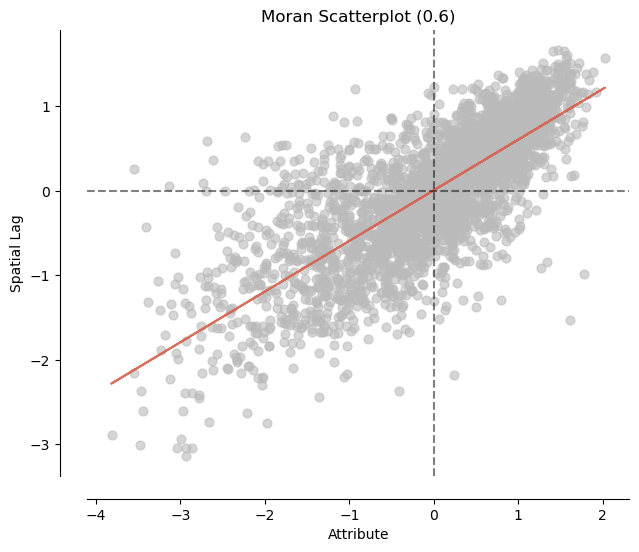

In [160]:
col = 'pct_gop_16'

mi = esda.Moran(gdf[col], w)
print('I:', mi.I)
print('p-sim:', mi.p_sim) 
moran_scatterplot(mi);

In [161]:
# https://pysal.org/esda/generated/esda.Moran_Local.html#esda.Moran_Local
lm = esda.Moran_Local(gdf[col], w, transformation = "r", 
    permutations = 999, geoda_quads=False)

lm.q

array([3, 3, 2, ..., 1, 1, 1])

In [162]:
gdf['lm_q'] = lm.q  # 1 HH, 2 LH, 3 LL, 4 HL
gdf['pval'] = lm.p_sim

In [163]:

pbins = [0.001, 0.01, 0.05]
bin_pval = mapclassify.UserDefined(gdf['pval'], pbins)
#gdf['pval_bin'] = bin_pval.yb
gdf['pval_bin'] = bin_pval.find_bin(gdf['pval']) 

In [164]:
set(bin_pval.yb==bin_pval.find_bin(gdf['pval']))

{True}

In [165]:
bin_pval

UserDefined

  Interval     Count
--------------------
[0.00, 0.00] |   298
(0.00, 0.01] |   396
(0.01, 0.05] |   502
(0.05, 0.50] |  1912

In [166]:
gdf.groupby(['pval_bin'])[['GEOID']].count()

,GEOID
pval_bin,
0,298
1,396
2,502
3,1912


in math, 
- `(` and `)` indicates NOT inclusive of the number;
- `[` and `]` indicates inclusive of the number

so `(0.00, 0.01]` means: greater than ($>$) 0.00 but less than and equal to ($\leq$) 0.01

<Axes: >

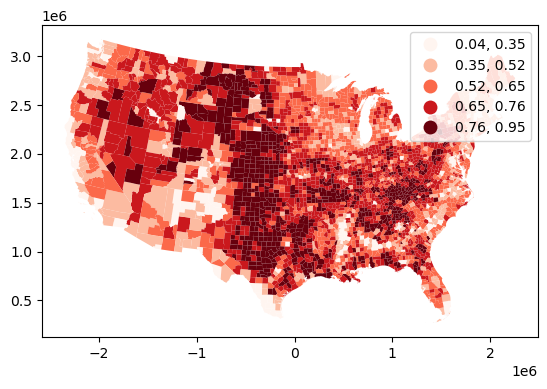

In [167]:
gdf.plot('pct_gop_16', scheme='naturalbreaks', legend=True, cmap='Reds')

In [168]:
sns.color_palette('Greens', 5)

[(0.8606689734717416, 0.9458362168396771, 0.8385697808535179),
 (0.681045751633987, 0.8718954248366013, 0.6562091503267974),
 (0.45176470588235296, 0.7670895809304115, 0.4612072279892349),
 (0.21568627450980393, 0.6287581699346405, 0.3333333333333333),
 (0.04359861591695502, 0.4648212226066897, 0.20369088811995384)]

In [169]:
pv_cmap = sns.color_palette('Greens', 5)
pv_cmap = pv_cmap[1:]  # first one too bright
pv_cmap = pv_cmap[::-1]  # reverse them all
pv_cmap = {i:c for i, c in enumerate(pv_cmap)}
pv_cmap_label = {0: '$\leq$ .001', 1: '$\leq$ .01', 2: '$\leq$ .05'}  # 3: >0.05

#1 HH, 2 LH, 3 LL, 4 HL
q_cmap = {
    1: 'xkcd:bright red', 
    2: 'xkcd:sky blue', 
    3: 'xkcd:electric blue', 
    4: 'xkcd:baby pink'}
q_cmap_label = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

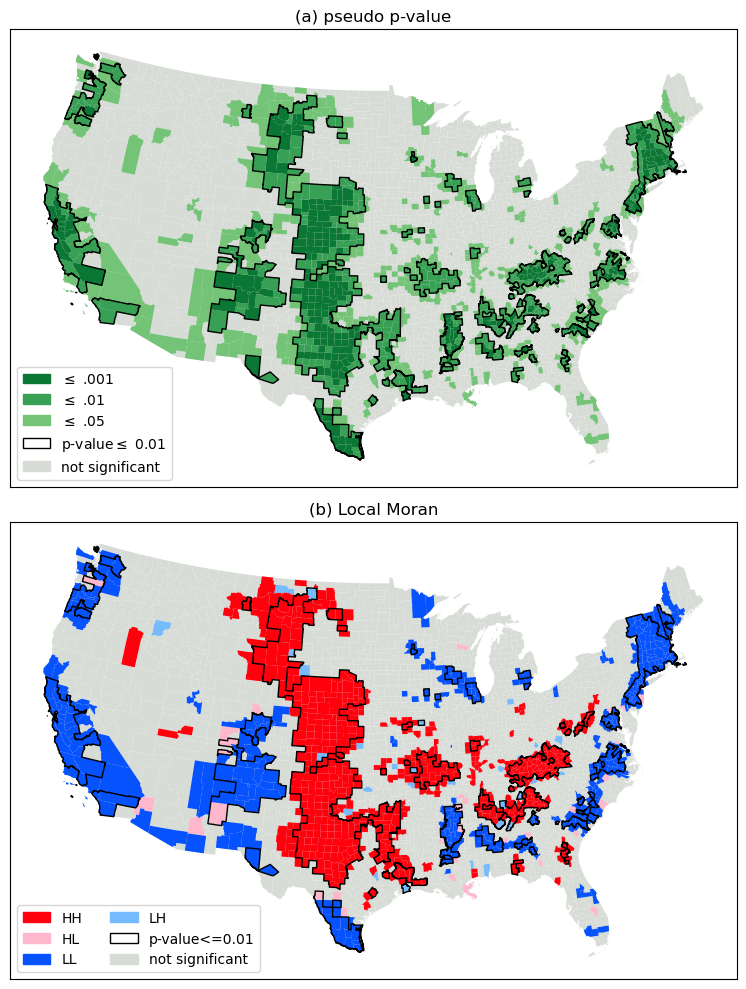

In [170]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

for ax in axs:
    gdf.plot(ax=ax, fc='xkcd:light grey')

ax = axs[0]
tmp = gdf[gdf['pval']<=0.05]
tmp.plot(ax=ax, color=[pv_cmap[a] for a in tmp['pval_bin']])
# to highlight the very significant places
tmp2 = gdf[gdf['pval']<=0.01]
tmp2 = tmp2.dissolve()
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
## manually compose legend
legend_elements = [Patch(facecolor=pv_cmap[i], edgecolor=pv_cmap[i],
                         label=pv_cmap_label[i]) for i in [0, 1, 2]]
legend_elements.append(Patch(facecolor='none', edgecolor='k',
                         label='p-value$\leq$ 0.01'))
legend_elements.append(Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant'))
ax.legend(handles=legend_elements, loc='lower left', ncol=1)


ax = axs[1]
tmp.plot(ax=ax, color=[q_cmap[a] for a in tmp['lm_q']])
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
## manually compose legend
legend_elements = [Patch(facecolor=q_cmap[i], edgecolor=q_cmap[i],
                         label=q_cmap_label[i]) for i in [1, 4, 3, 2]]
ax.legend(handles=legend_elements, loc='lower left', ncol=2)
legend_elements2 = [Patch(facecolor='none', edgecolor='k',
                         label='p-value<=0.01'), 
                    Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant')]
legend_elements.extend(legend_elements2)
ax.legend(handles=legend_elements, loc='lower left', ncol=2)

titles = ['(a) pseudo p-value', '(b) Local Moran']
for i, ax in enumerate(axs):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i])

plt.tight_layout()
#fig.savefig('local_moran_election_2016_gop.png', dpi=200, bbox_inches='tight')

In [171]:
#gdf.head()

## running Geary's C

In [172]:
w2 = weights.Queen.from_dataframe(gdf, ids='index')
w2.transform = 'R'

('WARNING: ', 1267, ' is an island (no neighbors)')
('WARNING: ', 2729, ' is an island (no neighbors)')
('WARNING: ', 2763, ' is an island (no neighbors)')


/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 1267, 2729, 2763.
  warnings.warn(message)


In [173]:
c = esda.Geary(gdf[col], w2, permutations=999)
c.C, c.p_sim

(0.3826319169440395, 0.001)

In [174]:
col = 'pct_gop_16'
# https://pysal.org/esda/generated/esda.Geary_Local.html#esda.Geary_Local
lc = esda.Geary_Local(connectivity=w2, permutations = 999, drop_islands=False, labels=True)
lc.fit(gdf[col])
lc.labs, lc.p_sim

(array([4., 4., 4., ..., 4., 1., 1.]),
 array([0.131, 0.213, 0.44 , ..., 0.265, 0.001, 0.001]))

In [175]:
gdf['lc_q'] = lc.labs  #labels: 1: 'HH Cluster', 2: 'LL Cluster', 3: 'Outlier', 4: 'Non-significant'
gdf['lc_pval'] = lc.p_sim
pbins = [0.001, 0.01, 0.05]
bin_pval = mapclassify.UserDefined(gdf['lc_pval'], pbins)
gdf['lc_pval_bin'] = bin_pval.find_bin(gdf['lc_pval'])

In [176]:
gdf.groupby(['lc_q'])[['index']].count()

,index
lc_q,
1.0,842
2.0,487
3.0,206
4.0,1573


In [177]:
pv_cmap = sns.color_palette('Greens', 5)
pv_cmap = pv_cmap[1:]  # first one too light
pv_cmap = pv_cmap[::-1]
pv_cmap = {i:c for i, c in enumerate(pv_cmap)}
pv_cmap_label = {0: '$\leq$ .001', 1: '$\leq$ .01', 2: '$\leq$ .05'}

# for the new label: lc_q_cmap_label_new
lc_q_cmap = {
    1: 'xkcd:bright red',  # HH cluster
    2: 'xkcd:electric blue',  # LL cluster
    3: 'xkcd:sunflower', # outliers
    4: 'xkcd:light grey',  # non-sig
    }  # other


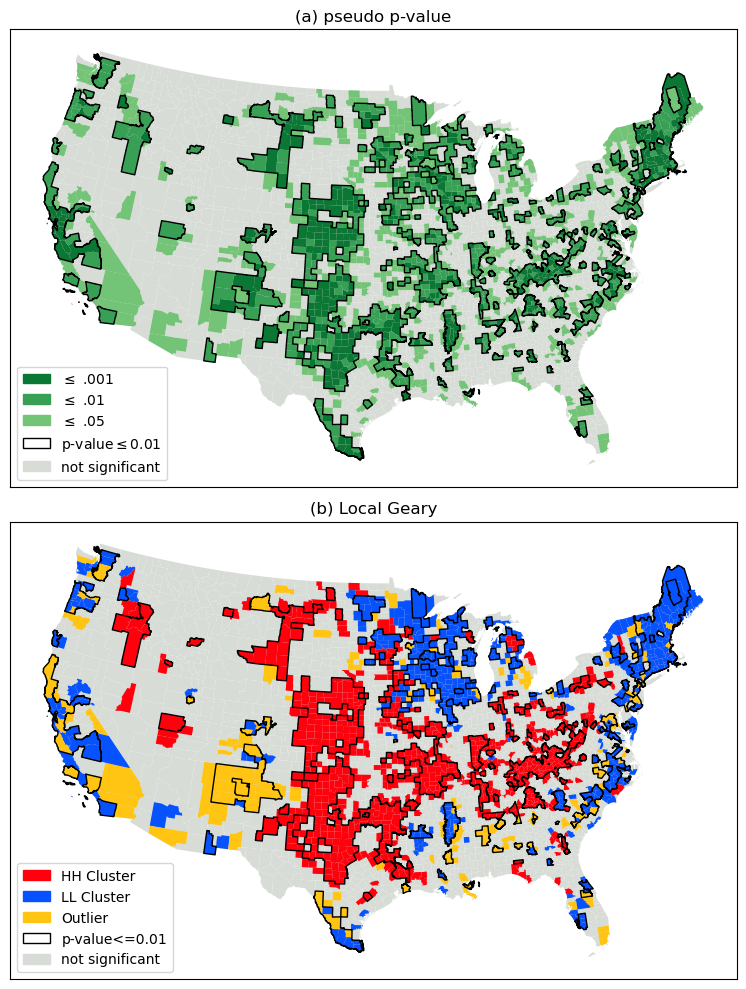

In [183]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

for ax in axs:
    gdf.plot(ax=ax, fc='xkcd:light grey')

ax = axs[0]
tmp = gdf[gdf['lc_pval']<=0.05]
tmp2 = gdf[gdf['lc_pval']<=0.01]
tmp2 = tmp2.dissolve()
tmp.plot(ax=ax, color=[pv_cmap[a] for a in tmp['lc_pval_bin']])
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor=pv_cmap[i], edgecolor=pv_cmap[i],
                         label=pv_cmap_label[i]) for i in [0, 1, 2]]
legend_elements.append(Patch(facecolor='none', edgecolor='k',
                         label='p-value$\leq$0.01'))
legend_elements.append(Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant'))
ax.legend(handles=legend_elements, loc='lower left', ncol=1)


ax = axs[1]
tmp.plot(ax=ax, color=[lc_q_cmap[a] for a in tmp['lc_q']])

tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor=lc_q_cmap[i], edgecolor=lc_q_cmap[i],
                         label=lc_q_cmap_label_new[i]) for i in [1, 2, 3]]
#ax.legend(handles=legend_elements, loc='lower left', ncol=2)
legend_elements2 = [Patch(facecolor='none', edgecolor='k',
                         label='p-value<=0.01'), 
                    Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant')]
legend_elements.extend(legend_elements2)
ax.legend(handles=legend_elements, loc='lower left', ncol=1)

titles = ['(a) pseudo p-value', '(b) Local Geary']
for i, ax in enumerate(axs):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i])

plt.tight_layout()
#fig.savefig('local_geary_election_2016_gop.png', dpi=200, bbox_inches='tight')

In [179]:
w3 = weights.Queen.from_dataframe(gdf, ids='index')
w3

/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 1267, 2729, 2763.
  warnings.warn(message)


In [180]:
lg = esda.G_Local(gdf[col], w3,transform='R', star=False)  # default no star
lg_star = esda.G_Local(gdf[col], w3,transform='R',star=True)

('WARNING: ', 1267, ' is an island (no neighbors)')
('WARNING: ', 2729, ' is an island (no neighbors)')
('WARNING: ', 2763, ' is an island (no neighbors)')


/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/esda/getisord.py:615: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  warnings.warn(
/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 1267, 2729, 2763.
  warnings.warn(message)


('WARNING: ', 1267, ' is an island (no neighbors)')
('WARNING: ', 2729, ' is an island (no neighbors)')
('WARNING: ', 2763, ' is an island (no neighbors)')


In [181]:
gdf['lg_zg'] = lg.Zs
gdf['lg_pval'] = lg.p_sim

gdf['lgs_zg'] = lg_star.Zs
gdf['lgs_pval'] = lg_star.p_sim

In [184]:
pbins = [0.001, 0.01, 0.05]

bin_pval = mapclassify.UserDefined(gdf['lg_pval'], pbins)
#gdf['pval_bin'] = bin_pval.yb
gdf['lg_pval_bin'] = bin_pval.find_bin(gdf['lg_pval'])


bin_pval = mapclassify.UserDefined(gdf['lgs_pval'], pbins)
#gdf['pval_bin'] = bin_pval.yb
gdf['lgs_pval_bin'] = bin_pval.find_bin(gdf['lgs_pval'])

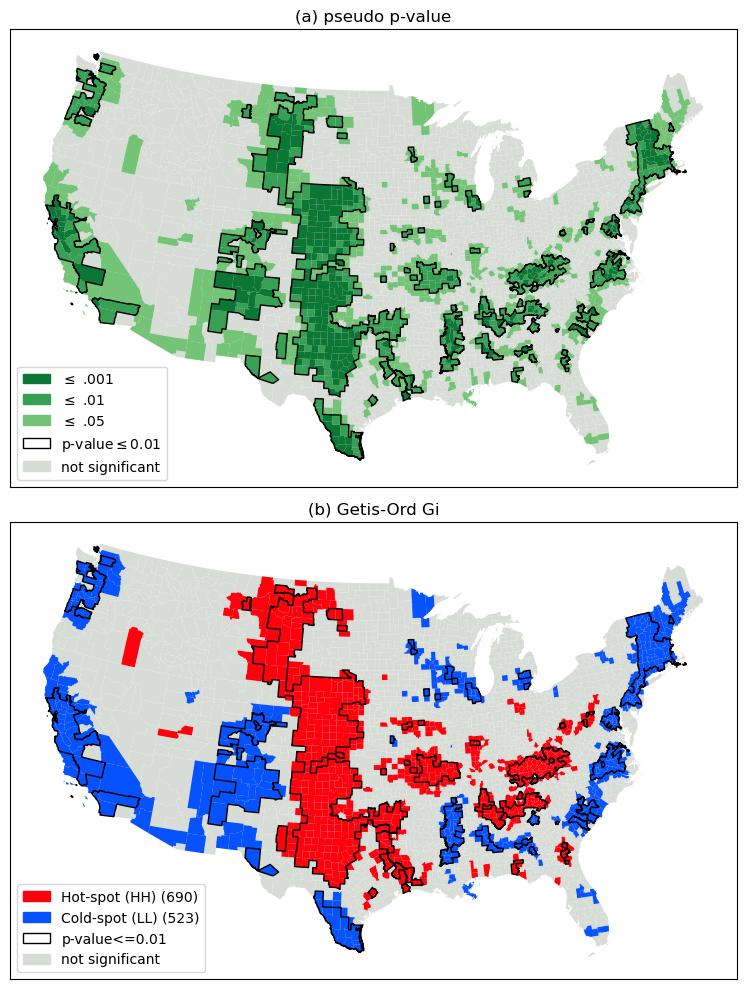

In [187]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

for ax in axs:
    gdf.plot(ax=ax, fc='xkcd:light grey')

ax = axs[0]
tmp = gdf[gdf['lg_pval']<=0.05]
tmp2 = gdf[gdf['lg_pval']<=0.01]
tmp2 = tmp2.dissolve()
tmp.plot(ax=ax, color=[pv_cmap[a] for a in tmp['lg_pval_bin']])
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor=pv_cmap[i], edgecolor=pv_cmap[i],
                         label=pv_cmap_label[i]) for i in [0, 1, 2]]
legend_elements.append(Patch(facecolor='none', edgecolor='k',
                         label='p-value$\leq$0.01'))
legend_elements.append(Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant'))
ax.legend(handles=legend_elements, loc='lower left', ncol=1)


ax = axs[1]
tmpa = tmp[tmp['lg_zg']>0]
tmpb = tmp[tmp['lg_zg']<0]
tmpa.plot(fc='xkcd:bright red', ax=ax)
tmpb.plot(fc='xkcd:electric blue', ax=ax)
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor='xkcd:bright red', edgecolor='xkcd:bright red',
                        label='{} ({})'.format('Hot-spot (HH)', len(tmpa))), 
                   Patch(facecolor='xkcd:electric blue', edgecolor='xkcd:electric blue',
                        label='{} ({})'.format('Cold-spot (LL)', len(tmpb))), ]
legend_elements2 = [Patch(facecolor='none', edgecolor='k',
                         label='p-value<=0.01'), 
                    Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant')]
legend_elements.extend(legend_elements2)
ax.legend(handles=legend_elements, loc='lower left', ncol=1)

titles = ['(a) pseudo p-value', '(b) Getis-Ord Gi']
for i, ax in enumerate(axs):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i])

plt.tight_layout()
#fig.savefig('local_gi_election_2016_gop.png', dpi=200, bbox_inches='tight')

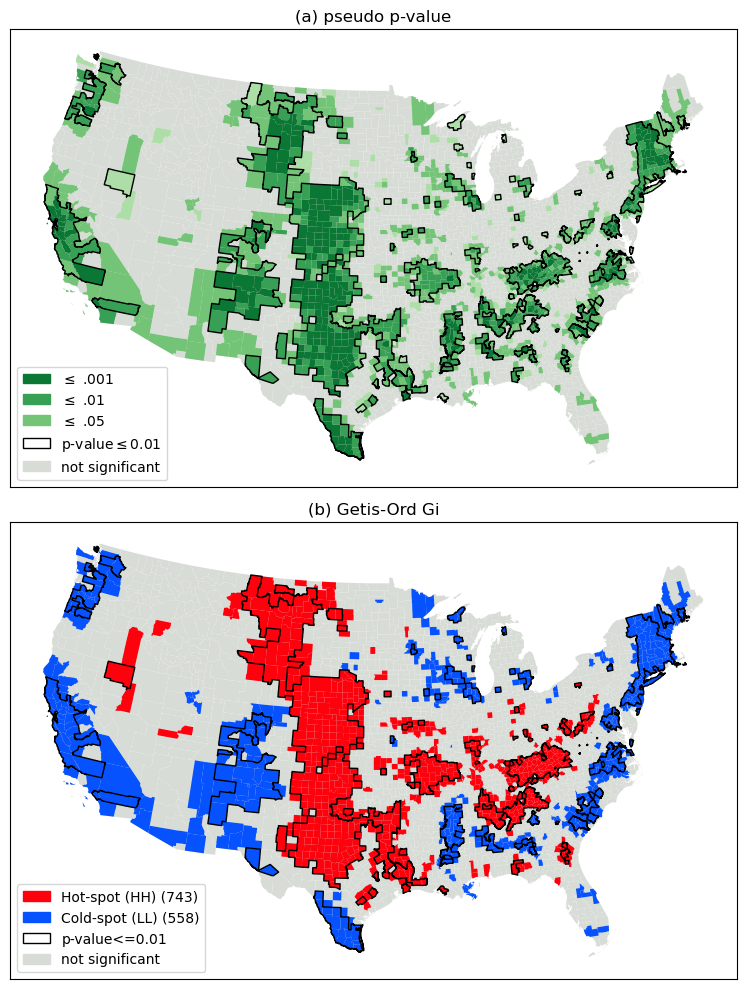

In [188]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

for ax in axs:
    gdf.plot(ax=ax, fc='xkcd:light grey')

ax = axs[0]
tmp = gdf[gdf['lgs_pval']<=0.05]
tmp2 = gdf[gdf['lgs_pval']<=0.01]
tmp2 = tmp2.dissolve()
tmp.plot(ax=ax, color=[pv_cmap[a] for a in tmp['lg_pval_bin']])
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor=pv_cmap[i], edgecolor=pv_cmap[i],
                         label=pv_cmap_label[i]) for i in [0, 1, 2]]
legend_elements.append(Patch(facecolor='none', edgecolor='k',
                         label='p-value$\leq$0.01'))
legend_elements.append(Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant'))
ax.legend(handles=legend_elements, loc='lower left', ncol=1)


ax = axs[1]
tmpa = tmp[tmp['lgs_zg']>0]
tmpb = tmp[tmp['lgs_zg']<0]
tmpa.plot(fc='xkcd:bright red', ax=ax)
tmpb.plot(fc='xkcd:electric blue', ax=ax)
tmp2.plot(ax=ax, fc='none', ec='k', lw=1)
legend_elements = [Patch(facecolor='xkcd:bright red', edgecolor='xkcd:bright red',
                        label='{} ({})'.format('Hot-spot (HH)', len(tmpa))), 
                   Patch(facecolor='xkcd:electric blue', edgecolor='xkcd:electric blue',
                        label='{} ({})'.format('Cold-spot (LL)', len(tmpb))), ]
legend_elements2 = [Patch(facecolor='none', edgecolor='k',
                         label='p-value<=0.01'), 
                    Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                         label='not significant')]
legend_elements.extend(legend_elements2)
ax.legend(handles=legend_elements, loc='lower left', ncol=1)

titles = ['(a) pseudo p-value', '(b) Getis-Ord Gi']
for i, ax in enumerate(axs):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i])

plt.tight_layout()
#fig.savefig('local_gi_election_2016_gop.png', dpi=200, bbox_inches='tight')

## identify places that is HH in all 3 methods

In [196]:
gdf.columns

Index(['index', 'STATEFP', 'COUNTYFP', 'GEOID', 'ALAND', 'AWATER', 'area_name',
       'state_abbr', 'PST045214', 'PST040210', 'PST120214', 'POP010210',
       'AGE135214', 'AGE295214', 'AGE775214', 'SEX255214', 'RHI125214',
       'RHI225214', 'RHI325214', 'RHI425214', 'RHI525214', 'RHI625214',
       'RHI725214', 'RHI825214', 'POP715213', 'POP645213', 'POP815213',
       'EDU635213', 'EDU685213', 'VET605213', 'LFE305213', 'HSG010214',
       'HSG445213', 'HSG096213', 'HSG495213', 'HSD410213', 'HSD310213',
       'INC910213', 'INC110213', 'PVY020213', 'BZA010213', 'BZA110213',
       'BZA115213', 'NES010213', 'SBO001207', 'SBO315207', 'SBO115207',
       'SBO215207', 'SBO515207', 'SBO415207', 'SBO015207', 'MAN450207',
       'WTN220207', 'RTN130207', 'RTN131207', 'AFN120207', 'BPS030214',
       'LND110210', 'POP060210', 'Demvotes16', 'GOPvotes16', 'total_2016',
       'pct_dem_16', 'pct_gop_16', 'diff_2016', 'pct_pt_16', 'total_2012',
       'Demvotes12', 'GOPvotes12', 'county_fip', 

<Axes: >

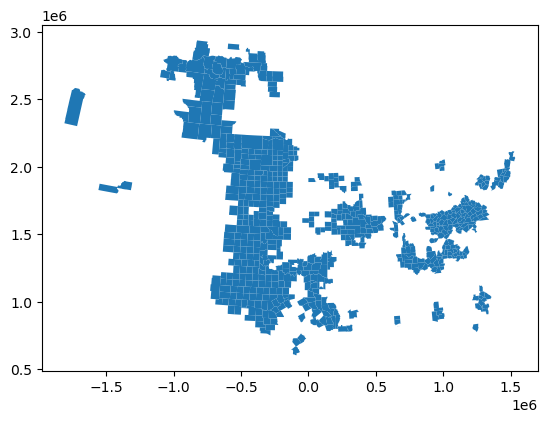

In [195]:
tmp = gdf[gdf['lm_q']==1]  # HH
tmp = tmp[tmp['pval']<=.05]
tmp.plot()

<Axes: >

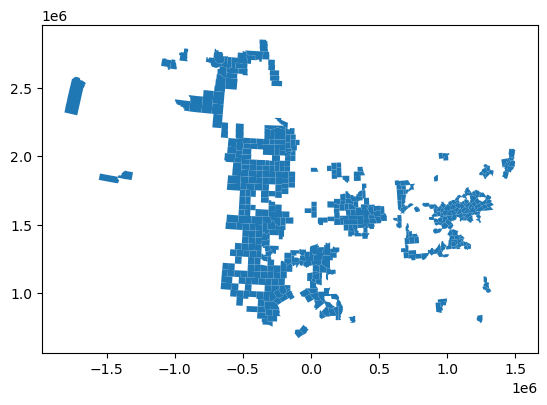

In [198]:
tmp2 = tmp[tmp['lc_q']==1]
tmp2 = tmp2[tmp2['lc_pval']<=.05]
tmp2.plot()

<Axes: >

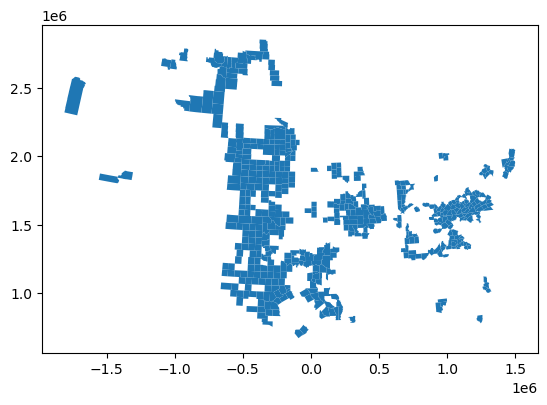

In [199]:
tmp3 = tmp2[tmp2['lgs_pval']<=.05]
tmp3 = tmp3[tmp3['lgs_zg']>0]
tmp3.plot()

## similarly for LL

<Axes: >

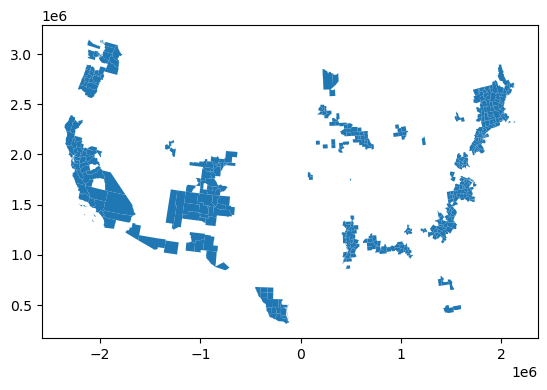

In [200]:
tmpb = gdf[gdf['lm_q']==3]  # LL
tmpb = tmpb[tmpb['pval']<=.05]
tmpb.plot()

<Axes: >

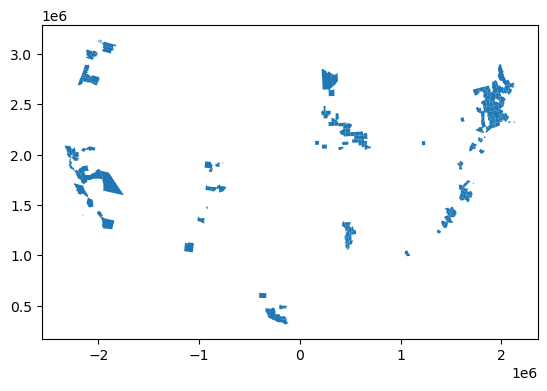

In [201]:
tmpb2 = tmpb[tmpb['lc_q']==2]
tmpb2 = tmpb2[tmpb2['lc_pval']<=.05]
tmpb2.plot()

<Axes: >

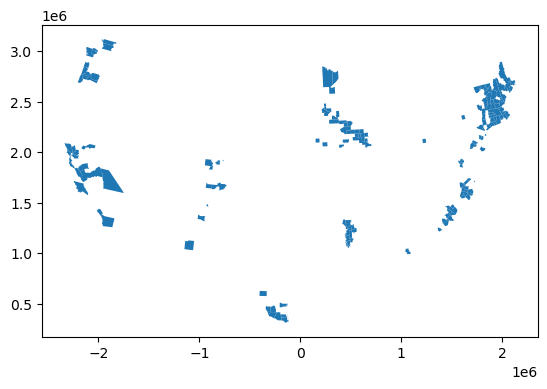

In [202]:
tmpb3 = tmpb2[tmpb2['lgs_pval']<=.05]
tmpb3 = tmpb3[tmpb3['lgs_zg']<0]
tmpb3.plot()

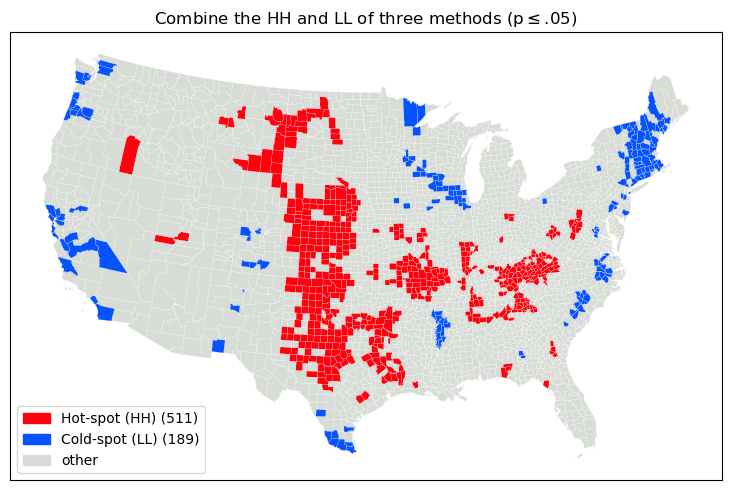

In [214]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharex=True, sharey=True)

gdf.plot(ax=ax, fc='xkcd:light grey')

tmp3.plot(ax=ax, fc='xkcd:bright red')
tmpb3.plot(ax=ax, fc='xkcd:electric blue')

gdf.plot(ax=ax, fc='none', ec='w', lw=.1)

legend_elements = [Patch(facecolor='xkcd:bright red', edgecolor='xkcd:bright red',
                        label='{} ({})'.format('Hot-spot (HH)', len(tmp3))), 
                   Patch(facecolor='xkcd:electric blue', edgecolor='xkcd:electric blue',
                        label='{} ({})'.format('Cold-spot (LL)', len(tmpb3))),
                   Patch(facecolor='xkcd:light grey', edgecolor='xkcd:light grey',
                        label='other')]
ax.legend(handles=legend_elements, loc='lower left', ncol=1)
ax.set_title('Combine the HH and LL of three methods (p$\leq$.05)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()